In [ ]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q accelerate datasets peft bitsandbytes

In [ ]:
from datasets import load_dataset
ds = load_dataset("SimulaMet-HOST/Kvasir-VQA")["raw"]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
ds

Dataset({
    features: ['image', 'source', 'question', 'answer', 'img_id'],
    num_rows: 58849
})

In [ ]:
import os
from datasets import Dataset, Features, Image, Value, load_dataset, DatasetDict
from PIL import Image as PILImage
import random
import pandas as pd
from collections import defaultdict

In [ ]:
from datasets import concatenate_datasets

valid_ds = ds.filter(lambda ex: ex["question"] and ex["question"] != "none")


abnormal_ids = set(
    ex["img_id"] for ex in valid_ds if ex["source"].lower() != "normal"
)

seen_ids = set()
added_examples = []
for ex in valid_ds:
    if ex["img_id"] in abnormal_ids and ex["img_id"] not in seen_ids:
        added_examples.append({
            "image": ex["image"],
            "source": ex["source"],
            "question": "Does this image contain any finding?",
            "answer": "yes",
            "img_id": ex["img_id"]
        })
        seen_ids.add(ex["img_id"])

modified_ds = Dataset.from_list(added_examples)
cleaned_ds = concatenate_datasets([valid_ds, modified_ds])


In [ ]:
# summary
print("Original size:", len(ds))
print("Cleaned size: ", len(valid_ds))
print("final modifierd data size: ", len(cleaned_ds))
print("new added QAs: ", len(added_examples))

Original size: 58849
Cleaned size:  58798
final modifierd data size:  62747
new added QAs:  3949


In [ ]:
cleaned_ds

Dataset({
    features: ['image', 'source', 'question', 'answer', 'img_id'],
    num_rows: 62747
})

In [ ]:
import random
from datasets import load_dataset, DatasetDict

all_ids = sorted(set(cleaned_ds["img_id"]))

# Shuffle & split those IDs into 80/10/10
random.seed(42)
random.shuffle(all_ids)

n = len(all_ids)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

train_ids = set(all_ids[:n_train])
val_ids   = set(all_ids[n_train : n_train + n_val])
test_ids  = set(all_ids[n_train + n_val :])



In [ ]:
def filter_by_id(example, id_set):
    return example["img_id"] in id_set



In [ ]:
train_ds = cleaned_ds.filter(lambda ex: filter_by_id(ex, train_ids),
                     batched=False)
val_ds   = cleaned_ds.filter(lambda ex: filter_by_id(ex, val_ids),
                     batched=False)
test_ds  = cleaned_ds.filter(lambda ex: filter_by_id(ex, test_ids),
                     batched=False)

In [ ]:
dataset = DatasetDict({
    "train":      train_ds,
    "validation": val_ds,
    "test":       test_ds,
})

print({k: len(v) for k, v in dataset.items()})

{'train': 50105, 'validation': 6287, 'test': 6355}


In [ ]:

dataset_full = dataset

data = dataset_full.remove_columns(["source", "img_id"])
data

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 50105
    })
    validation: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 6287
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 6355
    })
})

In [ ]:
data['train']

Dataset({
    features: ['image', 'question', 'answer'],
    num_rows: 50105
})

In [ ]:
data['train'].features

In [ ]:
data['train'][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=720x576>,
 'question': 'Are there any abnormalities in the image? Check all that are present.',
 'answer': 'ulcerative colitis'}

In [ ]:
dataset_full['test']

Dataset({
    features: ['image', 'source', 'question', 'answer', 'img_id'],
    num_rows: 6355
})

In [ ]:
from datasets import DatasetDict
import random, itertools, io
from tqdm.auto import tqdm
from PIL import Image, ImageFilter, ImageEnhance
import numpy as np

synonyms_dict = {
    "type": ["kind", "category"],
    "procedure": ["process", "test"],
    "image": ["picture", "visual"],
    "abnormalities": ["irregularities", "issues"],
    "present": ["visible", "detected"],
    "easy": ["simple", "straightforward"],
    "detect": ["identify", "locate"],
    "polyp": ["lesion", "mass", "growth"],
    "size": ["dimension", "measurement"],
    "instrument": ["tool", "equipment"],
    "removed": ["extracted", "taken out"],
    "where": ["in what part", "in which area", "location of"],
    "how many": ["number of", "count of", "total"]
}
insert_words = [
    "possibly","likely","evidently","apparently","visibly",
    "clinically","endoscopically","approximately","typically"
]

def synonym_replacement(q):
    return " ".join(
        random.choice(synonyms_dict.get(w.lower(), [w]))
        for w in q.split()
    )

def random_insertion(q):
    ws = q.split()
    if not ws: return q
    ins = random.choice(insert_words)
    i = random.randint(0, len(ws))
    return " ".join(ws[:i] + [ins] + ws[i:])

def random_deletion(q, p=0.2):
    ws = q.split()
    if len(ws) == 1: return q
    return " ".join(w for w in ws if random.random() > p)

# image perturbations
def add_gaussian_noise(img, mean=0, std=10):
    arr = np.array(img).astype(float)
    noise = np.random.normal(mean, std, arr.shape)
    return Image.fromarray(np.clip(arr+noise,0,255).astype(np.uint8))

def apply_blur(img, radius=2):
    return img.filter(ImageFilter.GaussianBlur(radius))

def shift_brightness(img, factor=0.7):
    return ImageEnhance.Brightness(img).enhance(factor)

def jpeg_compress(img, quality=25):
    buf = io.BytesIO()
    img.save(buf, "JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf)



In [ ]:
text_fns  = [synonym_replacement, random_insertion, random_deletion]

def augment_batch(batch):
    imgs = batch["image"]
    qs   = batch["question"]
    ans  = batch["answer"]

    new_imgs = []
    new_qs   = []
    new_ans  = []

    for img, q0, a in zip(imgs, qs, ans):

        new_imgs.append(img); new_qs.append(q0); new_ans.append(a)

        for r in range(1, len(text_fns)+1):
            for combo in itertools.combinations(text_fns, r):
                q = q0
                for fn in combo:
                    q = fn(q)
                new_imgs.append(img)
                new_qs.append(q)
                new_ans.append(a)

        img1 = shift_brightness(apply_blur(add_gaussian_noise(img)), factor=0.7)
        new_imgs.append(img1); new_qs.append(q0); new_ans.append(a)

        img2 = jpeg_compress(add_gaussian_noise(img), quality=25)
        new_imgs.append(img2); new_qs.append(q0); new_ans.append(a)

    return {
      "image":    new_imgs,
      "question": new_qs,
      "answer":   new_ans
    }


print("old train size:", len(data["train"]))

new_train = data["train"].map(
    augment_batch,
    batched=True,
    batch_size=512,
    remove_columns=data["train"].column_names,
    load_from_cache_file=False,
    desc="augmenting…"
)

data = DatasetDict({
    "train":       new_train,
    "validation":  data["validation"],
    "test":        data["test"],
})

print("new train size:", len(data["train"]))

old train size: 50105


augmenting…:   0%|          | 0/50105 [00:00<?, ? examples/s]

new train size: 501050


In [ ]:
data['train']

Dataset({
    features: ['image', 'question', 'answer'],
    num_rows: 501050
})

In [ ]:
new_train

Dataset({
    features: ['image', 'question', 'answer'],
    num_rows: 501050
})

In [ ]:
data

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 501050
    })
    validation: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 6287
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 6355
    })
})

In [ ]:
import torch
from peft import LoraConfig
from transformers import AutoProcessor, BitsAndBytesConfig, Idefics3ForConditionalGeneration

DEVICE = "cuda"
USE_LORA = True
USE_8BIT = True

processor = AutoProcessor.from_pretrained(
    "HuggingFaceM4/Idefics3-8B-Llama3",
    do_image_splitting=False
)


lora_config = LoraConfig(
    r=8,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules='.*(text_model|modality_projection|perceiver_resampler).*(down_proj|gate_proj|up_proj|k_proj|q_proj|v_proj|o_proj).*$',
    use_dora=True,
    init_lora_weights="gaussian"
)


bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False
)


model = Idefics3ForConditionalGeneration.from_pretrained(
    "HuggingFaceM4/Idefics3-8B-Llama3",
    quantization_config=bnb_config,
    device_map="auto"
)

model.add_adapter(lora_config)
model.enable_adapters()


In [ ]:

def print_trainable_parameters(model):
    trainable = 0
    total = 0
    for name, param in model.named_parameters():
        total += param.numel()
        if param.requires_grad:
            trainable += param.numel()
    print(f"Trainable parameters: {trainable:,}")


print_trainable_parameters(model)

Trainable parameters: 22,347,776


In [ ]:
for name, module in model.named_modules():
    print(name)


model
model.vision_model
model.vision_model.embeddings
model.vision_model.embeddings.patch_embedding
model.vision_model.embeddings.position_embedding
model.vision_model.encoder
model.vision_model.encoder.layers
model.vision_model.encoder.layers.0
model.vision_model.encoder.layers.0.self_attn
model.vision_model.encoder.layers.0.self_attn.k_proj
model.vision_model.encoder.layers.0.self_attn.v_proj
model.vision_model.encoder.layers.0.self_attn.q_proj
model.vision_model.encoder.layers.0.self_attn.out_proj
model.vision_model.encoder.layers.0.layer_norm1
model.vision_model.encoder.layers.0.mlp
model.vision_model.encoder.layers.0.mlp.activation_fn
model.vision_model.encoder.layers.0.mlp.fc1
model.vision_model.encoder.layers.0.mlp.fc2
model.vision_model.encoder.layers.0.layer_norm2
model.vision_model.encoder.layers.1
model.vision_model.encoder.layers.1.self_attn
model.vision_model.encoder.layers.1.self_attn.k_proj
model.vision_model.encoder.layers.1.self_attn.v_proj
model.vision_model.encoder

In [ ]:
print("All special tokens:", processor.tokenizer.all_special_tokens)
print("Additional special tokens:", processor.tokenizer.additional_special_tokens)

In [ ]:
processor.tokenizer.additional_special_tokens_ids[processor.tokenizer.additional_special_tokens.index("<image>")]

128257

In [ ]:
data['train']

Dataset({
    features: ['image', 'question', 'answer'],
    num_rows: 501050
})

In [ ]:
class MyDataCollator:
    def __init__(self, processor):
        self.processor = processor
        self.image_token_id = processor.tokenizer.additional_special_tokens_ids[
            processor.tokenizer.additional_special_tokens.index("<image>")
        ]

    def __call__(self, examples):
        texts = []
        images = []
        for example in examples:
            image = example["image"]
            question = example["question"]
            answer = example["answer"]
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": "Answer as a medical specialist"},
                        {"type": "image"},
                        {"type": "text", "text": question}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [
                        {"type": "text", "text": answer}
                    ]
                }
            ]
            text = processor.apply_chat_template(messages, add_generation_prompt=False)
            texts.append(text.strip())
            images.append([image])

        batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

        labels = batch["input_ids"].clone()
        labels[labels == processor.tokenizer.pad_token_id] = -100
        labels[labels == self.image_token_id] = -100
        batch["labels"] = labels

        return batch

data_collator = MyDataCollator(processor)


In [ ]:
data_collator

In [ ]:
data_collator([data['train'][0]])

{'pixel_values': tensor([[[[[-0.9686, -0.9686, -0.9686,  ..., -0.9686, -0.9765, -0.9843],
           [-0.9686, -0.9686, -0.9686,  ..., -0.9686, -0.9765, -0.9843],
           [-0.9686, -0.9686, -0.9686,  ..., -0.9686, -0.9765, -0.9843],
           ...,
           [-0.9922, -0.9922, -0.9765,  ..., -0.9843, -1.0000, -1.0000],
           [-0.9922, -0.9922, -0.9765,  ..., -0.9843, -1.0000, -1.0000],
           [-0.9922, -0.9922, -0.9765,  ..., -0.9843, -1.0000, -1.0000]],

          [[-0.9686, -0.9686, -0.9686,  ..., -0.9686, -0.9765, -0.9843],
           [-0.9686, -0.9686, -0.9686,  ..., -0.9686, -0.9765, -0.9843],
           [-0.9686, -0.9686, -0.9686,  ..., -0.9686, -0.9765, -0.9843],
           ...,
           [-0.9922, -0.9922, -0.9765,  ..., -0.9843, -1.0000, -1.0000],
           [-0.9922, -0.9922, -0.9765,  ..., -0.9843, -1.0000, -1.0000],
           [-0.9922, -0.9922, -0.9765,  ..., -0.9843, -1.0000, -1.0000]],

          [[-0.9686, -0.9686, -0.9686,  ..., -0.9843, -0.9922, -1.0000]

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True, 
    warmup_steps=50,
    learning_rate=1e-4, 
    lr_scheduler_type="constant", 
    weight_decay=0.01,
    output_dir=r"idefics3_checkpoint_lora_adv_training",
    optim="paged_adamw_8bit",
    save_total_limit=1,
    # fp16=True, 
    bf16=True,
    remove_unused_columns=False,
    report_to="none",
 
    logging_steps=200,  
    eval_steps=200, 
    eval_strategy="steps", 
    save_strategy="steps", 
    save_steps=400, 
    metric_for_best_model="eval_loss", 
    greater_is_better=False, 
    load_best_model_at_end=True, 

)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=data['train'],
    eval_dataset=data['validation'], 
)


In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [ ]:
trainer.train()

In [ ]:
import evaluate
import torch
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import Levenshtein


In [ ]:
def clean_answer(text):
    if "Assistant:" in text:
        return text.split("Assistant:")[-1].strip()
    return text.strip()

In [ ]:
preds = []
refs = []

for ex in tqdm(data['test']):
    image = ex["image"]
    question = ex["question"]
    answer = ex["answer"] 

    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

    inputs = processor(text=prompt, images=[[image]], return_tensors="pt", padding=True).to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=64)
    pred = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
    pred = clean_answer(pred)

    preds.append(pred)
    refs.append(answer if isinstance(answer, list) else [answer])



In [ ]:
# !pip install evaluate scikit-learn nltk rouge-score Levenshtein

In [ ]:

refs_single = [r[0] for r in refs]

accuracy = sum(p in r for p, r in zip(preds, refs)) / len(refs) * 100

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")

bleu_res   = bleu.compute(predictions=preds, references=[[r] for r in refs_single])
rouge_res  = rouge.compute(predictions=preds, references=refs_single)
meteor_res = meteor.compute(predictions=preds, references=refs_single)

# Jaccard Similarity
j_scores = []
for r, p in zip(refs_single, preds):
    set_r, set_p = set(r.split()), set(p.split())
    j_scores.append(len(set_r & set_p) / len(set_r | set_p) if (set_r | set_p) else 0)
jaccard = sum(j_scores) / len(j_scores) * 100

# Cosine Similarity 
vectorizer = TfidfVectorizer().fit(refs_single + preds)
ref_vecs  = vectorizer.transform(refs_single)
pred_vecs = vectorizer.transform(preds)
cos_sims  = cosine_similarity(ref_vecs, pred_vecs).diagonal()
cosine = cos_sims.mean() * 100

# Levenshtein Similarity
def normalized_levenshtein(s1, s2):
    if not s1 and not s2:
        return 0
    return Levenshtein.distance(s1, s2) / max(len(s1), len(s2))

def similarity_score(a_ij, o_q_i, tau=0.5):
    nl = normalized_levenshtein(a_ij, o_q_i)
    return 1 - nl if nl < tau else 0

def average_levenshtein_similarity(ground_truth, predicted):
    total_score = 0
    for refs, pred in zip(ground_truth, predicted):
        if not pred:
            continue
        max_score = max(similarity_score(ref, pred) for ref in refs)
        total_score += max_score
    return total_score / len(ground_truth) * 100

levenshtein_score = average_levenshtein_similarity(refs, preds)



In [ ]:

results = {
    "accuracy (%)": round(accuracy, 2),
    "bleu": bleu_res,
    "rouge": rouge_res,
    "meteor": meteor_res,
    "jaccard (%)": round(jaccard, 2),
    "cosine (%)": round(cosine, 2),
    "levenshtein (%)": round(levenshtein_score, 2)
}

for k, v in results.items():
    print(f"{k}:\n{v}\n")

###  Generation

In [ ]:
#all 19 questions
questions = [
    "What type of procedure is the image taken from?",
    "Is there text?",
    "Is there a green/black box artefact?",
    "Does this image contain any finding?",
    "Are there any abnormalities in the image? Check all that are present.",
    "Is this finding easy to detect?",
    "What type of polyp is present?",
    "What is the size of the polyp?",
    "What color is the abnormality? If more than one separate with ;",
    "Where in the image is the abnormality?",
    "How many findings are present?",
    "How many polyps are in the image?",
    "Are there any anatomical landmarks in the image? Check all that are present.",
    "What color is the anatomical landmark?",
    "Where in the image is the anatomical landmark?",
    "Are there any instruments in the image? Check all that are present.",
    "How many instruments are in the image?",
    "Where in the image is the instrument?",
    "Have all polyps been removed?"
]

In [ ]:
def build_report(sample, answers):
    lines = [
        "Automated Pathology Report",
        f"Image ID : {sample['img_id']}",
        ""
    ]

    sections = {
        "": {
            0: "Procedure Type"
        },
        "Findings & Abnormalities": {
            3: "Presence of Finding",
            10: "Number of Findings",
            4: "Abnormalities Detected",
            8: "Abnormality Color",
            9: "Abnormality Location"
        },
        "Polyp Details": {
            6: "Polyp Type",
            7: "Polyp Size",
            11: "Number of Polyps",
            18: "Polyp Removal Status"
        },
        "Anatomical Landmarks": {
            12: "Landmark Presence",
            13: "Landmark Color",
            14: "Landmark Location"
        },
        "Presence of Instrument": {
            15: "Instrument"
        }
    }

    for section, items in sections.items():
        if section: 
            lines.append(section)
        for idx, label in items.items():
            lines.append(f"{label}: {answers[idx]}")
        lines.append("")  

    return "\n".join(lines)


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_report(sample, answers):
    report_lines = build_report(sample, answers).split("\n")
    fig = plt.figure(figsize=(6, 10))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 5], hspace=0.3)

    ax_img = fig.add_subplot(gs[0])
    img = sample["image"].resize((224, 224)).convert("RGB")
    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title(f"Image ID: {sample['img_id']}")

    ax_txt = fig.add_subplot(gs[1])
    ax_txt.axis("off")
    ax_txt.text(0, 1, "\n".join(report_lines[3:]), va="top", family="monospace", fontsize=10, wrap=True)
    plt.show()


In [ ]:
def clean_answer(text):
    if "Assistant:" in text:
        return text.split("Assistant:")[-1].strip()
    return text.strip()

def generate_medical_report(img_id=None, image_file=None):

    if img_id:
        sample = next(item for item in dataset_full["test"] if item["img_id"] == img_id)
        image = sample["image"]
        img_id_str = img_id
    elif image_file:
        image = Image.open(image_file).convert("RGB")
        sample = {"image": image, "img_id": "external_image"}
        img_id_str = "external_image"
    else:
        raise ValueError("Either img_id or image_file must be provided.")


    messages_list = [
        [{"role": "user", "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": q}
        ]}]
        for q in questions
    ]
    prompts = [processor.apply_chat_template(m, add_generation_prompt=True) for m in messages_list]

    inputs = processor(text=prompts, images=[[image]] * len(prompts), return_tensors="pt", padding=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=64)

    preds = processor.batch_decode(outputs, skip_special_tokens=True)
    preds = [clean_answer(p) for p in preds]

    sample["img_id"] = img_id_str
    plot_report(sample, preds)


In [ ]:
def print_ground_truth_answers(img_id, dataset):
    entries = [e for e in dataset if e['img_id'] == img_id]
    if not entries:
        print("Image ID not found in dataset.")
        return
    print(f"Ground Truth for Image ID: {img_id}\n")
    for i, entry in enumerate(entries):
        print(f"Q{i+1}: {entry['question']}")
        print(f"A{i+1}: {entry['answer']}\n")

In [ ]:
generate_medical_report(img_id="cl8k2u1rj1g9n08326w2q2o28")

## Load model from checkpoint

In [ ]:
from transformers import AutoProcessor, BitsAndBytesConfig, Idefics3ForConditionalGeneration
from peft import PeftModel, PeftConfig
import torch

In [ ]:
processor1 = AutoProcessor.from_pretrained(
    "HuggingFaceM4/Idefics3-8B-Llama3",
    do_image_splitting=False
)

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False
)

base_model1 = Idefics3ForConditionalGeneration.from_pretrained(
    "HuggingFaceM4/Idefics3-8B-Llama3",
    quantization_config=bnb_config,
    device_map="auto"
)


In [ ]:
from peft import PeftModel

model1 = PeftModel.from_pretrained(
    base_model1,
    "idefics3_checkpoint_lora_adv_training/checkpoint-31316",
    is_trainable=False 
)
model1.eval()


PeftModel(
  (base_model): LoraModel(
    (model): Idefics3ForConditionalGeneration(
      (model): Idefics3Model(
        (vision_model): Idefics3VisionTransformer(
          (embeddings): Idefics3VisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedding(676, 1152)
          )
          (encoder): Idefics3Encoder(
            (layers): ModuleList(
              (0-26): 27 x Idefics3EncoderLayer(
                (self_attn): Idefics3VisionAttention(
                  (k_proj): Linear8bitLt(in_features=1152, out_features=1152, bias=True)
                  (v_proj): Linear8bitLt(in_features=1152, out_features=1152, bias=True)
                  (q_proj): Linear8bitLt(in_features=1152, out_features=1152, bias=True)
                  (out_proj): Linear8bitLt(in_features=1152, out_features=1152, bias=True)
                )
                (layer_norm1): LayerNorm((1152,), eps=1e-06, elem

In [ ]:
def generate_medical_report1(img_id=None, image_file=None):

    if img_id:
        sample = next(item for item in dataset_full["test"] if item["img_id"] == img_id)
        image = sample["image"]
        img_id_str = img_id
    elif image_file:
        image = Image.open(image_file).convert("RGB")
        sample = {"image": image, "img_id": "external_image"}
        img_id_str = "external_image"
    else:
        raise ValueError("Either img_id or image_file must be provided.")


    messages_list = [
        [{"role": "user", "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": q}
        ]}]
        for q in questions
    ]
    prompts = [processor1.apply_chat_template(m, add_generation_prompt=True) for m in messages_list]


    inputs = processor1(text=prompts, images=[[image]] * len(prompts), return_tensors="pt", padding=True).to(model1.device)
    with torch.no_grad():
        outputs = model1.generate(**inputs, max_new_tokens=64)

    preds = processor1.batch_decode(outputs, skip_special_tokens=True)
    preds = [clean_answer(p) for p in preds]

    sample["img_id"] = img_id_str
    plot_report(sample, preds)

In [ ]:
generate_medical_report1(img_id="cl8k2u1rj1g9n08326w2q2o28")

In [ ]:
import evaluate
import torch
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import Levenshtein

def clean_answer(text):
    if "Assistant:" in text:
        return text.split("Assistant:")[-1].strip()
    return text.strip()

In [ ]:

preds1 = []
refs1 = []

for ex in tqdm(data['test']):
    image = ex["image"]
    question = ex["question"]
    answer = ex["answer"]  


    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }]
    prompt = processor1.apply_chat_template(messages, add_generation_prompt=True)


    inputs = processor1(text=prompt, images=[[image]], return_tensors="pt", padding=True).to(model1.device)
    with torch.no_grad():
        output_ids = model1.generate(**inputs, max_new_tokens=64)
    pred = processor1.batch_decode(output_ids, skip_special_tokens=True)[0]
    pred = clean_answer(pred)

    preds1.append(pred)
    refs1.append(answer if isinstance(answer, list) else [answer])

100%|██████████| 6355/6355 [5:58:07<00:00,  3.38s/it]   


In [ ]:


refs1_single1 = [r[0] for r in refs1]

accuracy = sum(p in r for p, r in zip(preds1, refs1)) / len(refs1) * 100


bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")

bleu_res   = bleu.compute(predictions=preds1, references=[[r] for r in refs1_single1])
rouge_res  = rouge.compute(predictions=preds1, references=refs1_single1)
meteor_res = meteor.compute(predictions=preds1, references=refs1_single1)

# Jaccard Similarity
j_scores = []
for r, p in zip(refs1_single1, preds1):
    set_r, set_p = set(r.split()), set(p.split())
    j_scores.append(len(set_r & set_p) / len(set_r | set_p) if (set_r | set_p) else 0)
jaccard = sum(j_scores) / len(j_scores) * 100

# Cosine Similarity 
vectorizer = TfidfVectorizer().fit(refs1_single1 + preds1)
ref_vecs  = vectorizer.transform(refs1_single1)
pred_vecs = vectorizer.transform(preds1)
cos_sims  = cosine_similarity(ref_vecs, pred_vecs).diagonal()
cosine = cos_sims.mean() * 100

# Levenshtein Similarity
def normalized_levenshtein(s1, s2):
    if not s1 and not s2:
        return 0
    return Levenshtein.distance(s1, s2) / max(len(s1), len(s2))

def similarity_score(a_ij, o_q_i, tau=0.5):
    nl = normalized_levenshtein(a_ij, o_q_i)
    return 1 - nl if nl < tau else 0

def average_levenshtein_similarity(ground_truth, predicted):
    total_score = 0
    for refs1, pred in zip(ground_truth, predicted):
        if not pred:
            continue
        max_score = max(similarity_score(ref, pred) for ref in refs1)
        total_score += max_score
    return total_score / len(ground_truth) * 100

levenshtein_score = average_levenshtein_similarity(refs1, preds1)

results = {
    "accuracy (%)": round(accuracy, 2),
    "bleu": bleu_res,
    "rouge": rouge_res,
    "meteor": meteor_res,
    "jaccard (%)": round(jaccard, 2),
    "cosine (%)": round(cosine, 2),
    "levenshtein (%)": round(levenshtein_score, 2)
}

for k, v in results.items():
    print(f"{k}:\n{v}\n")

[nltk_data] Downloading package wordnet to /home/ebmi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/ebmi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/ebmi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


accuracy (%):
87.02

bleu:
{'bleu': 0.803765590313617, 'precisions': [0.8836264223437269, 0.8113943446162418, 0.768731356378312, 0.7572553897180763], 'brevity_penalty': 1.0, 'length_ratio': 1.0341560327042103, 'translation_length': 13534, 'reference_length': 13087}

rouge:
{'rouge1': 0.9243782094873942, 'rouge2': 0.17971917825213032, 'rougeL': 0.9221575144130206, 'rougeLsum': 0.9222881241500663}

meteor:
{'meteor': 0.5361777763389692}

jaccard (%):
89.97

cosine (%):
77.58

levenshtein (%):
91.01



## Adversarial Robustness Analysis

In [ ]:
synonyms_dict = {
    "type": ["kind", "category"],
    "procedure": ["process", "test"],
    "image": ["picture", "visual"],
    "abnormalities": ["irregularities", "issues"],
    "present": ["visible", "detected"],
    "easy": ["simple", "straightforward"],
    "detect": ["identify", "locate"],
    "polyp": ["lesion", "mass", "growth"],
    "size": ["dimension", "measurement"],
    "instrument": ["tool", "equipment"],
    "removed": ["extracted", "taken out"],
    "where": ["in what part", "in which area", "location of"],
    "how many": ["number of", "count of", "total"]
}


In [ ]:
insert_words = [
    "possibly", "likely", "evidently", "apparently", "visibly",
    "clinically", "endoscopically", "approximately", "typically"
]


In [ ]:
import random

def synonym_replacement(question, synonyms_dict):
    words = question.split()
    new_words = [random.choice(synonyms_dict.get(w.lower(), [w])) for w in words]
    return " ".join(new_words)

def random_insertion(question, insert_words):
    words = question.split()
    if not words: return question
    insert_word = random.choice(insert_words)
    insert_pos = random.randint(0, len(words))
    return " ".join(words[:insert_pos] + [insert_word] + words[insert_pos:])

def random_deletion(question, p=0.2):
    words = question.split()
    if len(words) == 1: return question
    return " ".join([w for w in words if random.random() > p])


In [ ]:
attacked_preds = []
for ex in tqdm(data['test']):
    image = ex["image"]
    question = ex["question"]
    answer = ex["answer"]

    # only synonum replacement
    attacked_q = synonym_replacement(question, synonyms_dict)

    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": attacked_q}
        ]
    }]
    prompt = processor1.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor1(text=prompt, images=[[image]], return_tensors="pt", padding=True).to(model1.device)

    with torch.no_grad():
        output_ids = model1.generate(**inputs, max_new_tokens=64)

    pred = processor1.batch_decode(output_ids, skip_special_tokens=True)[0]
    pred = clean_answer(pred)
    attacked_preds.append(pred)


100%|██████████| 6355/6355 [5:58:24<00:00,  3.38s/it]   


preds1 and refs1 are from previous execution (before attack) for comparison

In [ ]:

acc_at_attack = sum(p in r for p, r in zip(attacked_preds, refs1)) / len(refs1) * 100


asr = sum(p1 != p2 for p1, p2 in zip(preds1, attacked_preds)) / len(preds1) * 100


In [ ]:
print(f"Acc@Attack (%): {acc_at_attack:.3f}")
print(f"Attack Success Rate (ASR %): {asr:.3f}")


Acc@Attack (%): 86.829
Attack Success Rate (ASR %): 0.677


In [ ]:

refs1_single = [r[0] for r in refs1]


adv_accuracy = sum(p in r for p, r in zip(attacked_preds, refs1)) / len(refs1) * 100


bleu_res_adv   = bleu.compute(predictions=attacked_preds, references=[[r] for r in refs1_single])
rouge_res_adv  = rouge.compute(predictions=attacked_preds, references=refs1_single)
meteor_res_adv = meteor.compute(predictions=attacked_preds, references=refs1_single)


j_scores_adv = []
for r, p in zip(refs1_single, attacked_preds):
    set_r, set_p = set(r.split()), set(p.split())
    j_scores_adv.append(len(set_r & set_p) / len(set_r | set_p) if (set_r | set_p) else 0)
jaccard_adv = sum(j_scores_adv) / len(j_scores_adv) * 100


vectorizer_adv = TfidfVectorizer().fit(refs1_single + attacked_preds)
ref_vecs_adv  = vectorizer_adv.transform(refs1_single)
pred_vecs_adv = vectorizer_adv.transform(attacked_preds)
cos_sims_adv  = cosine_similarity(ref_vecs_adv, pred_vecs_adv).diagonal()
cosine_adv = cos_sims_adv.mean() * 100


def normalized_levenshtein(s1, s2):
    if not s1 and not s2:
        return 0
    return Levenshtein.distance(s1, s2) / max(len(s1), len(s2))

def similarity_score(a_ij, o_q_i, tau=0.5):
    nl = normalized_levenshtein(a_ij, o_q_i)
    return 1 - nl if nl < tau else 0

def average_levenshtein_similarity(ground_truth, predicted):
    total_score = 0
    for refs, pred in zip(ground_truth, predicted):
        if not pred:
            continue
        max_score = max(similarity_score(ref, pred) for ref in refs)
        total_score += max_score
    return total_score / len(ground_truth) * 100

levenshtein_adv = average_levenshtein_similarity(refs1, attacked_preds)

adv_results = {
    "accuracy (%)": round(adv_accuracy, 2),
    "bleu": bleu_res_adv,
    "rouge": rouge_res_adv,
    "meteor": meteor_res_adv,
    "jaccard (%)": round(jaccard_adv, 2),
    "cosine (%)": round(cosine_adv, 2),
    "levenshtein (%)": round(levenshtein_adv, 2)
}

for k, v in adv_results.items():
    print(f"{k}:\n{v}\n")


accuracy (%):
86.83

bleu:
{'bleu': 0.8038420636870489, 'precisions': [0.8837861783815711, 0.8119349005424955, 0.7685834502103787, 0.7570480928689884], 'brevity_penalty': 1.0, 'length_ratio': 1.0349201497669442, 'translation_length': 13544, 'reference_length': 13087}

rouge:
{'rouge1': 0.9236383297964905, 'rouge2': 0.17935991570769352, 'rougeL': 0.921421761380973, 'rougeLsum': 0.9215231931287685}

meteor:
{'meteor': 0.5357280206073908}

jaccard (%):
89.89

cosine (%):
77.51

levenshtein (%):
90.97



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_text_perturbations(data, preds_clean, preds_perturbed, perturb_fn, num_samples=5):
    indices = np.random.choice(len(data), size=num_samples, replace=False)

    for idx in indices:
        sample = data[int(idx)]
        image = sample["image"]
        question = sample["question"]
        answer = sample["answer"]

        perturbed_question = perturb_fn(question)

   
        plt.figure(figsize=(10, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title("Text Perturbation Example", fontsize=12)


        full_text = (
            f"Ground Truth: {answer}\n"
            f"Original Q: {question}\n"
            f"Original A: {preds_clean[int(idx)]}\n"
            f"Perturbed Q: {perturbed_question}\n"
            f"Perturbed A: {preds_perturbed[int(idx)]}"
        )
        plt.figtext(0.5, -0.13, full_text, wrap=True, ha="center", fontsize=9)
        plt.tight_layout()
        plt.show()

In [ ]:
visualize_text_perturbations(
    data=data['test'],
    preds_clean=preds1,
    preds_perturbed=attacked_preds,
    perturb_fn=lambda q: synonym_replacement(q, synonyms_dict),
    num_samples=5
)


## with all three types of perturbations

In [ ]:
attacked_preds = []
for ex in tqdm(data['test']):
    image = ex["image"]
    question = ex["question"]
    answer = ex["answer"]

    attacked_q = synonym_replacement(question, synonyms_dict)
    attacked_q = random_insertion(attacked_q, insert_words)
    attacked_q = random_deletion(attacked_q)

    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": attacked_q}
        ]
    }]
    prompt = processor1.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor1(text=prompt, images=[[image]], return_tensors="pt", padding=True).to(model1.device)

    with torch.no_grad():
        output_ids = model1.generate(**inputs, max_new_tokens=64)

    pred = processor1.batch_decode(output_ids, skip_special_tokens=True)[0]
    pred = clean_answer(pred)
    attacked_preds.append(pred)

100%|██████████| 6355/6355 [6:01:03<00:00,  3.41s/it]   


In [ ]:

acc_at_attack = sum(p in r for p, r in zip(attacked_preds, refs1)) / len(refs1) * 100


asr = sum(p1 != p2 for p1, p2 in zip(preds1, attacked_preds)) / len(preds1) * 100

In [ ]:
print(f"Acc@Attack (%): {acc_at_attack:.3f}")
print(f"Attack Success Rate (ASR %): {asr:.3f}")


Acc@Attack (%): 85.539
Attack Success Rate (ASR %): 3.210


In [ ]:

refs1_single = [r[0] for r in refs1]


adv_accuracy = sum(p in r for p, r in zip(attacked_preds, refs1)) / len(refs1) * 100


bleu_res_adv   = bleu.compute(predictions=attacked_preds, references=[[r] for r in refs1_single])
rouge_res_adv  = rouge.compute(predictions=attacked_preds, references=refs1_single)
meteor_res_adv = meteor.compute(predictions=attacked_preds, references=refs1_single)

# Jaccard Similarity
j_scores_adv = []
for r, p in zip(refs1_single, attacked_preds):
    set_r, set_p = set(r.split()), set(p.split())
    j_scores_adv.append(len(set_r & set_p) / len(set_r | set_p) if (set_r | set_p) else 0)
jaccard_adv = sum(j_scores_adv) / len(j_scores_adv) * 100

# Cosine Similarity
vectorizer_adv = TfidfVectorizer().fit(refs1_single + attacked_preds)
ref_vecs_adv  = vectorizer_adv.transform(refs1_single)
pred_vecs_adv = vectorizer_adv.transform(attacked_preds)
cos_sims_adv  = cosine_similarity(ref_vecs_adv, pred_vecs_adv).diagonal()
cosine_adv = cos_sims_adv.mean() * 100

# Levenshtein Similarity
def normalized_levenshtein(s1, s2):
    if not s1 and not s2:
        return 0
    return Levenshtein.distance(s1, s2) / max(len(s1), len(s2))

def similarity_score(a_ij, o_q_i, tau=0.5):
    nl = normalized_levenshtein(a_ij, o_q_i)
    return 1 - nl if nl < tau else 0

def average_levenshtein_similarity(ground_truth, predicted):
    total_score = 0
    for refs, pred in zip(ground_truth, predicted):
        if not pred:
            continue
        max_score = max(similarity_score(ref, pred) for ref in refs)
        total_score += max_score
    return total_score / len(ground_truth) * 100

levenshtein_adv = average_levenshtein_similarity(refs1, attacked_preds)

adv_results = {
    "accuracy (%)": round(adv_accuracy, 2),
    "bleu": bleu_res_adv,
    "rouge": rouge_res_adv,
    "meteor": meteor_res_adv,
    "jaccard (%)": round(jaccard_adv, 2),
    "cosine (%)": round(cosine_adv, 2),
    "levenshtein (%)": round(levenshtein_adv, 2)
}

for k, v in adv_results.items():
    print(f"{k}:\n{v}\n")


accuracy (%):
85.54

bleu:
{'bleu': 0.7498459073265794, 'precisions': [0.8473021189834705, 0.7588777446462456, 0.7095681625740897, 0.6929212362911267], 'brevity_penalty': 1.0, 'length_ratio': 1.0493619622526171, 'translation_length': 13733, 'reference_length': 13087}

rouge:
{'rouge1': 0.9087315537977625, 'rouge2': 0.17400107512457674, 'rougeL': 0.9065624864826463, 'rougeLsum': 0.906774597907807}

meteor:
{'meteor': 0.52540629832423}

jaccard (%):
88.43

cosine (%):
76.38

levenshtein (%):
89.47



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_text_perturbations(data, preds_clean, preds_perturbed, perturb_fn, num_samples=5):
    indices = np.random.choice(len(data), size=num_samples, replace=False)

    for idx in indices:
        sample = data[int(idx)]
        image = sample["image"]
        question = sample["question"]
        answer = sample["answer"]

        perturbed_question = perturb_fn(question)

   
        plt.figure(figsize=(10, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title("Text Perturbation", fontsize=12)

  
        full_text = (

            f"Original Q: {question}\n"
            f"Original A: {preds_clean[int(idx)]}\n"
            f"Perturbed Q: {perturbed_question}\n"
            f"Perturbed A: {preds_perturbed[int(idx)]}"
        )
        plt.figtext(0.5, -0.12, full_text, wrap=True, ha="center", fontsize=9)
        plt.tight_layout()
        plt.show()

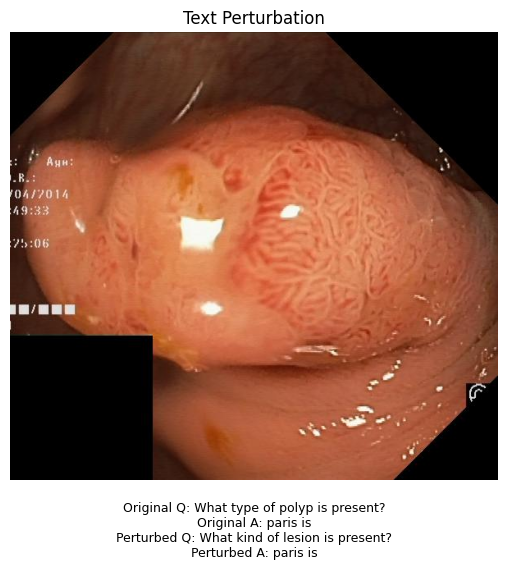

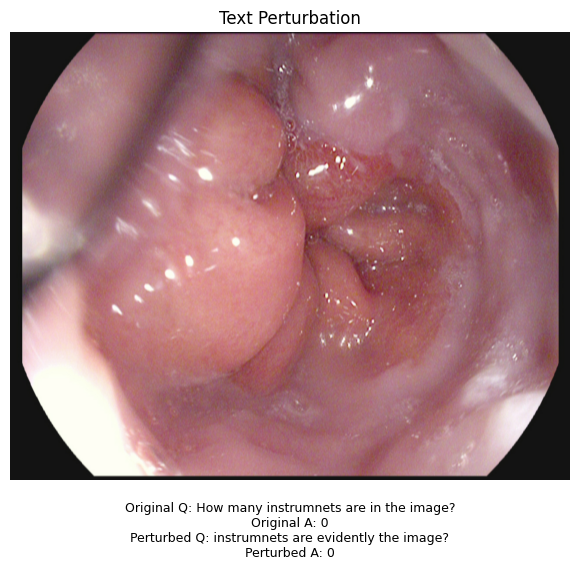

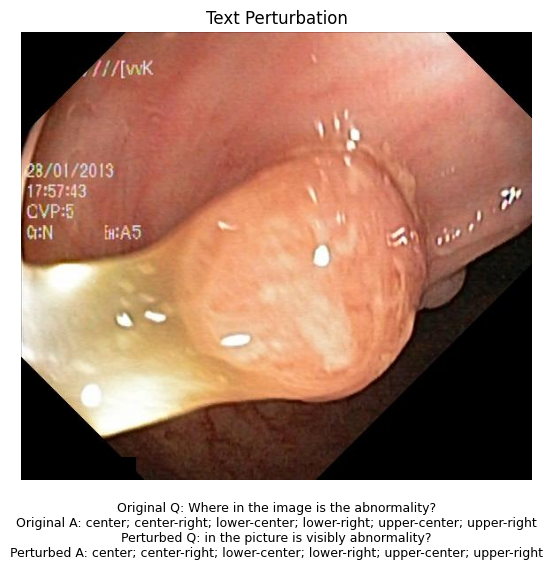

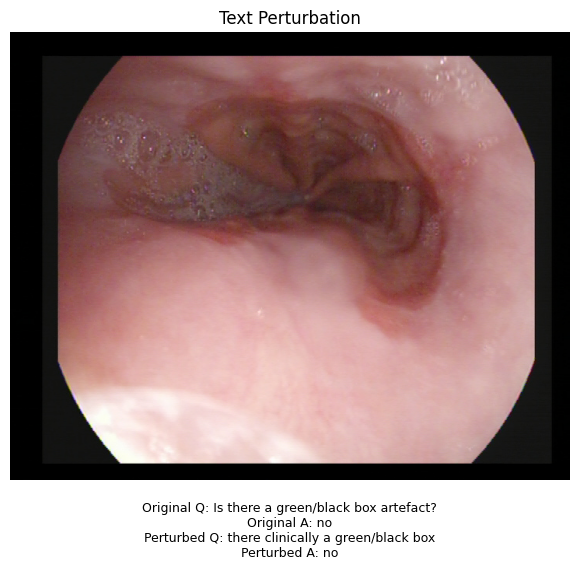

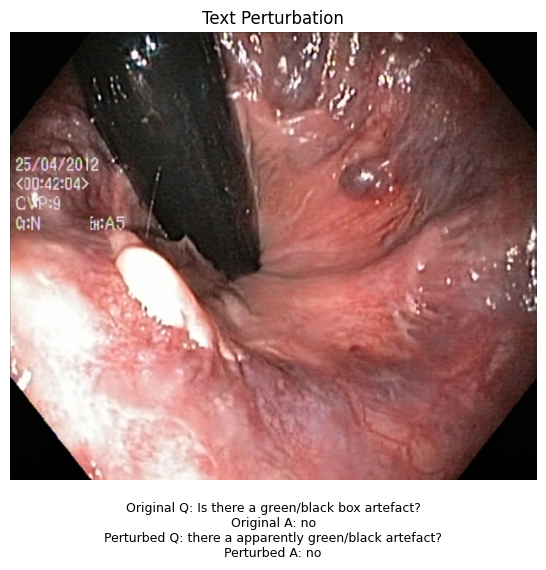

In [ ]:


def full_perturbation(q):
    q = synonym_replacement(q, synonyms_dict)
    q = random_insertion(q, insert_words)
    q = random_deletion(q)
    return q

visualize_text_perturbations(
    data=data['test'],
    preds_clean=preds1,
    preds_perturbed=attacked_preds,
    perturb_fn=full_perturbation,
    num_samples=5
)

## Image Perturbations

In [ ]:
from PIL import Image, ImageFilter, ImageEnhance
import torchvision.transforms as T
import numpy as np
import io

# Gaussian noise
def add_gaussian_noise(img, mean=0, std=10):
    np_img = np.array(img).astype(np.float32)
    noise = np.random.normal(mean, std, np_img.shape)
    noisy_img = np.clip(np_img + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy_img)

# Gaussian blur
def apply_blur(img, radius=2):
    return img.filter(ImageFilter.GaussianBlur(radius))


def shift_brightness(img, factor=1.5): 
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(factor)


def jpeg_compress(img, quality=30):
    buffer = io.BytesIO()
    img.save(buffer, format='JPEG', quality=quality)
    return Image.open(buffer)


In [ ]:

image_attacked_preds = []

for ex in tqdm(data['test']):
    image = ex["image"]
    question = ex["question"]
    answer = ex["answer"]


    perturbed_image = add_gaussian_noise(image)
    perturbed_image = apply_blur(perturbed_image)
    perturbed_image = shift_brightness(perturbed_image, factor=0.7)



    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }]
    prompt = processor1.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor1(text=prompt, images=[[perturbed_image]], return_tensors="pt", padding=True).to(model1.device)

    with torch.no_grad():
        output_ids = model1.generate(**inputs, max_new_tokens=64)

    pred = processor1.batch_decode(output_ids, skip_special_tokens=True)[0]
    pred = clean_answer(pred)
    image_attacked_preds.append(pred)



100%|██████████| 6355/6355 [6:04:38<00:00,  3.44s/it]   


In [ ]:

acc_at_attack_img = sum(p in r for p, r in zip(image_attacked_preds, refs1)) / len(refs1) * 100


asr_img = sum(p1 != p2 for p1, p2 in zip(preds1, image_attacked_preds)) / len(preds1) * 100

print(f"Image Acc@Attack (%): {acc_at_attack_img:.2f}")
print(f"Image ASR (%): {asr_img:.2f}")

Image Acc@Attack (%): 86.56
Image ASR (%): 5.79


In [ ]:

refs1_single = [r[0] for r in refs1]

adv_accuracy = sum(p in r for p, r in zip(image_attacked_preds, refs1)) / len(refs1) * 100

# Evaluate metrics
bleu_res_adv   = bleu.compute(predictions=image_attacked_preds, references=[[r] for r in refs1_single])
rouge_res_adv  = rouge.compute(predictions=image_attacked_preds, references=refs1_single)
meteor_res_adv = meteor.compute(predictions=image_attacked_preds, references=refs1_single)

# Jaccard Similarity
j_scores_adv = []
for r, p in zip(refs1_single, image_attacked_preds):
    set_r, set_p = set(r.split()), set(p.split())
    j_scores_adv.append(len(set_r & set_p) / len(set_r | set_p) if (set_r | set_p) else 0)
jaccard_adv = sum(j_scores_adv) / len(j_scores_adv) * 100


vectorizer_adv = TfidfVectorizer().fit(refs1_single + image_attacked_preds)
ref_vecs_adv  = vectorizer_adv.transform(refs1_single)
pred_vecs_adv = vectorizer_adv.transform(image_attacked_preds)
cos_sims_adv  = cosine_similarity(ref_vecs_adv, pred_vecs_adv).diagonal()
cosine_adv = cos_sims_adv.mean() * 100


def normalized_levenshtein(s1, s2):
    if not s1 and not s2:
        return 0
    return Levenshtein.distance(s1, s2) / max(len(s1), len(s2))

def similarity_score(a_ij, o_q_i, tau=0.5):
    nl = normalized_levenshtein(a_ij, o_q_i)
    return 1 - nl if nl < tau else 0

def average_levenshtein_similarity(ground_truth, predicted):
    total_score = 0
    for refs, pred in zip(ground_truth, predicted):
        if not pred:
            continue
        max_score = max(similarity_score(ref, pred) for ref in refs)
        total_score += max_score
    return total_score / len(ground_truth) * 100

levenshtein_adv = average_levenshtein_similarity(refs1, image_attacked_preds)

adv_results = {
    "accuracy (%)": round(adv_accuracy, 2),
    "bleu": bleu_res_adv,
    "rouge": rouge_res_adv,
    "meteor": meteor_res_adv,
    "jaccard (%)": round(jaccard_adv, 2),
    "cosine (%)": round(cosine_adv, 2),
    "levenshtein (%)": round(levenshtein_adv, 2)
}

for k, v in adv_results.items():
    print(f"{k}:\n{v}\n")

accuracy (%):
86.56

bleu:
{'bleu': 0.7997083849542593, 'precisions': [0.8798586572438163, 0.8085489002628302, 0.7637726638772664, 0.752737037802107], 'brevity_penalty': 1.0, 'length_ratio': 1.0379766180178804, 'translation_length': 13584, 'reference_length': 13087}

rouge:
{'rouge1': 0.919485216677885, 'rouge2': 0.1810033959942191, 'rougeL': 0.9175768473953776, 'rougeLsum': 0.917746607039305}

meteor:
{'meteor': 0.5334182766591266}

jaccard (%):
89.54

cosine (%):
77.19

levenshtein (%):
90.52



In [ ]:
def run_single_image_perturbed_inference(img_id, question, dataset, model, processor):
    sample = get_sample_by_img_id(dataset, img_id)
    if sample is None:
        print(f"Image ID {img_id} not found.")
        return

    image = sample["image"]
    perturbed_image = apply_image_perturbations(image)

    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=prompt, images=[[perturbed_image]], return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=64)
    pred = processor.batch_decode(output_ids, skip_special_tokens=True)[0]


    ground_truth = sample["answer"]


    plt.imshow(perturbed_image)
    plt.axis('off')
    plt.title("Perturbed Image")
    plt.show()

    print(f" Image ID: {img_id}")
    print(f" Question: {question}")
    print(f"Ground Truth: {ground_truth}")
    print(f" Predicted Answer: {pred}")


In [ ]:
def run_single_image_perturbed_inference(img_id, question, dataset, model, processor):
    def clean_answer(text):
        if "Assistant:" in text:
            return text.split("Assistant:")[-1].strip()
        return text.strip()

    sample = get_sample_by_img_id(dataset, img_id)
    if sample is None:
        print(f"Image ID {img_id} not found.")
        return

    image = sample["image"]
    perturbed_image = apply_image_perturbations(image)

    # Build prompt
    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=prompt, images=[[perturbed_image]], return_tensors="pt", padding=True).to(model.device)

    # Generate
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=64)
    pred = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
    pred = clean_answer(pred) 

    # Display perturbed image
    plt.imshow(perturbed_image)
    plt.axis('off')
    plt.title("Perturbed Image")
    plt.show()


    ground_truth = sample["answer"]

  
    print(f"Image ID: {img_id}")
    print(f"Question: {question}")
    print(f"Generated Answer: {pred}")


In [ ]:
run_single_image_perturbed_inference(
    img_id="cla820gl2s3qz071u9ed6awtv",
    question="What color is the abnormality?",
    dataset=dataset_full["test"],
    model=model1,
    processor=processor1
)


### lowering image quality

In [ ]:
# Image perturbation evaluation
image_attacked_preds = []

for ex in tqdm(data['test']):
    image = ex["image"]
    question = ex["question"]
    answer = ex["answer"]

   

    perturbed_image = jpeg_compress(image, quality=25)

    messages = [{
        "role": "user",
        "content": [
            {"type": "text", "text": "Answer as a medical specialist"},
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }]
    prompt = processor1.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor1(text=prompt, images=[[perturbed_image]], return_tensors="pt", padding=True).to(model1.device)

    with torch.no_grad():
        output_ids = model1.generate(**inputs, max_new_tokens=64)

    pred = processor1.batch_decode(output_ids, skip_special_tokens=True)[0]
    pred = clean_answer(pred)
    image_attacked_preds.append(pred)


In [ ]:

acc_at_attack_img = sum(p in r for p, r in zip(image_attacked_preds, refs1)) / len(refs1) * 100

asr_img = sum(p1 != p2 for p1, p2 in zip(preds1, image_attacked_preds)) / len(preds1) * 100

print(f"Image Acc@Attack (%): {acc_at_attack_img:.2f}")
print(f"Image ASR (%): {asr_img:.2f}")

Image Acc@Attack (%): 86.85
Image ASR (%): 4.39


In [ ]:

refs1_single = [r[0] for r in refs1]


adv_accuracy = sum(p in r for p, r in zip(image_attacked_preds, refs1)) / len(refs1) * 100


bleu_res_adv   = bleu.compute(predictions=image_attacked_preds, references=[[r] for r in refs1_single])
rouge_res_adv  = rouge.compute(predictions=image_attacked_preds, references=refs1_single)
meteor_res_adv = meteor.compute(predictions=image_attacked_preds, references=refs1_single)

# Jaccard Similarity
j_scores_adv = []
for r, p in zip(refs1_single, image_attacked_preds):
    set_r, set_p = set(r.split()), set(p.split())
    j_scores_adv.append(len(set_r & set_p) / len(set_r | set_p) if (set_r | set_p) else 0)
jaccard_adv = sum(j_scores_adv) / len(j_scores_adv) * 100

# Cosine Similarity 
vectorizer_adv = TfidfVectorizer().fit(refs1_single + image_attacked_preds)
ref_vecs_adv  = vectorizer_adv.transform(refs1_single)
pred_vecs_adv = vectorizer_adv.transform(image_attacked_preds)
cos_sims_adv  = cosine_similarity(ref_vecs_adv, pred_vecs_adv).diagonal()
cosine_adv = cos_sims_adv.mean() * 100

# Levenshtein Similarity
def normalized_levenshtein(s1, s2):
    if not s1 and not s2:
        return 0
    return Levenshtein.distance(s1, s2) / max(len(s1), len(s2))

def similarity_score(a_ij, o_q_i, tau=0.5):
    nl = normalized_levenshtein(a_ij, o_q_i)
    return 1 - nl if nl < tau else 0

def average_levenshtein_similarity(ground_truth, predicted):
    total_score = 0
    for refs, pred in zip(ground_truth, predicted):
        if not pred:
            continue
        max_score = max(similarity_score(ref, pred) for ref in refs)
        total_score += max_score
    return total_score / len(ground_truth) * 100

levenshtein_adv = average_levenshtein_similarity(refs1, image_attacked_preds)

adv_results = {
    "accuracy (%)": round(adv_accuracy, 2),
    "bleu": bleu_res_adv,
    "rouge": rouge_res_adv,
    "meteor": meteor_res_adv,
    "jaccard (%)": round(jaccard_adv, 2),
    "cosine (%)": round(cosine_adv, 2),
    "levenshtein (%)": round(levenshtein_adv, 2)
}

for k, v in adv_results.items():
    print(f"{k}:\n{v}\n")

accuracy (%):
86.85

bleu:
{'bleu': 0.803867312354457, 'precisions': [0.883166568569747, 0.8113859333978167, 0.7688424717145343, 0.7579316028018129], 'brevity_penalty': 1.0, 'length_ratio': 1.0385879116680676, 'translation_length': 13592, 'reference_length': 13087}

rouge:
{'rouge1': 0.9241800037886396, 'rouge2': 0.1805880085183557, 'rougeL': 0.9219621236956619, 'rougeLsum': 0.9221934588741203}

meteor:
{'meteor': 0.5354961958285994}

jaccard (%):
89.91

cosine (%):
77.65

levenshtein (%):
90.99



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_perturbed_samples(data, preds_clean, preds_perturbed, perturb_fn, num_samples=5):
    indices = np.random.choice(len(data), size=num_samples, replace=False)

    for idx in indices:
        sample = data[int(idx)]
        image = sample["image"]
        question = sample["question"]
        answer = sample["answer"]

        perturbed_image = perturb_fn(image)

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"Question: {question}", fontsize=11)

        axs[0].imshow(image)
        axs[0].set_title("Original")
        axs[0].axis("off")
        axs[0].text(0, -10, f"GT: {answer}", fontsize=9, color='green')
        axs[0].text(0, -25, f"Pred: {preds_clean[int(idx)]}", fontsize=9, color='blue')

        axs[1].imshow(perturbed_image)
        axs[1].set_title("Perturbed")
        axs[1].axis("off")
        axs[1].text(0, -10, f"Pred: {preds_perturbed[int(idx)]}", fontsize=9, color='red')

        plt.tight_layout()
        plt.show()


In [ ]:
# Example using Gaussian noise visualization
visualize_perturbed_samples(
    data=data['test'],
    preds_clean=preds,
    preds_perturbed=image_attacked_preds,
    perturb_fn=jpeg_compress,
    num_samples=5
)